In [2]:
import pandas as pd
import numpy as np
import sqlite3

,date,nav,fund_name
0,01-06-2026,6156.7532,Axis_Bluechip
1,29-05-2026,6151.1139,Axis_Bluechip
2,27-05-2026,6146.6118,Axis_Bluechip
3,26-05-2026,6144.0004,Axis_Bluechip
4,25-05-2026,6144.8478,Axis_Bluechip


In [2]:
conn = sqlite3.connect("../data/db/bluestock_mf.db")

df = pd.read_sql("SELECT * FROM nav_history", conn)

df.head()

,date,nav,fund_name
0,01-06-2026,6156.7532,Axis_Bluechip
1,29-05-2026,6151.1139,Axis_Bluechip
2,27-05-2026,6146.6118,Axis_Bluechip
3,26-05-2026,6144.0004,Axis_Bluechip
4,25-05-2026,6144.8478,Axis_Bluechip


In [3]:
df["date"] = pd.to_datetime(df["date"], dayfirst=True)

df = df.sort_values(["fund_name", "date"])

In [4]:
df["daily_return"] = df.groupby("fund_name")["nav"].pct_change()

df = df.dropna(subset=["daily_return"])

In [5]:
cagr = df.groupby("fund_name").apply(
    lambda x: (x["nav"].iloc[-1] / x["nav"].iloc[0]) ** (1 / (len(x)/252)) - 1
)

print(cagr)

fund_name
Axis_Bluechip      0.480287
HDFC_Top100_NAV    0.244899
ICICI_Bluechip     0.157842
Kotak_Bluechip     0.172821
Nippon_LargeCap    0.155131
SBI_Bluechip       0.001255
dtype: float64


In [6]:
volatility = df.groupby("fund_name")["daily_return"].std() * np.sqrt(252)

print(volatility)

fund_name
Axis_Bluechip      26.336085
HDFC_Top100_NAV     0.152125
ICICI_Bluechip           NaN
Kotak_Bluechip      0.154287
Nippon_LargeCap     0.167012
SBI_Bluechip        0.087164
Name: daily_return, dtype: float64


In [7]:
risk_free_rate = 0.06

sharpe = (
    df.groupby("fund_name")["daily_return"].mean() * 252 - risk_free_rate
) / volatility

print(sharpe)

fund_name
Axis_Bluechip      0.266160
HDFC_Top100_NAV    1.123378
ICICI_Bluechip          NaN
Kotak_Bluechip     0.722514
Nippon_LargeCap    0.589642
SBI_Bluechip      -0.628819
Name: daily_return, dtype: float64


In [8]:
metrics = pd.DataFrame({
    "CAGR": cagr,
    "Volatility": volatility,
    "Sharpe Ratio": sharpe
})

metrics.sort_values("Sharpe Ratio", ascending=False)

,CAGR,Volatility,Sharpe Ratio
fund_name,,,
HDFC_Top100_NAV,0.244899,0.152125,1.123378
Kotak_Bluechip,0.172821,0.154287,0.722514
Nippon_LargeCap,0.155131,0.167012,0.589642
Axis_Bluechip,0.480287,26.336085,0.266160
SBI_Bluechip,0.001255,0.087164,-0.628819
ICICI_Bluechip,0.157842,NaN,NaN


In [9]:
metrics.to_csv("../data/processed/performance_metrics.csv")

print("Saved successfully")

Saved successfully


In [3]:
import pandas as pd
import sqlite3

conn = sqlite3.connect("../data/db/bluestock_mf.db")

df = pd.read_sql("SELECT * FROM nav_history", conn)

df.head()

,date,nav,fund_name
0,01-06-2026,6156.7532,Axis_Bluechip
1,29-05-2026,6151.1139,Axis_Bluechip
2,27-05-2026,6146.6118,Axis_Bluechip
3,26-05-2026,6144.0004,Axis_Bluechip
4,25-05-2026,6144.8478,Axis_Bluechip


In [4]:
print(df[df["fund_name"] == "ICICI_Bluechip"].shape)

(3307, 3)


In [5]:
import pandas as pd
import numpy as np
import sqlite3

conn = sqlite3.connect("../data/db/bluestock_mf.db")

df = pd.read_sql("SELECT * FROM nav_history", conn)

In [6]:
df["date"] = pd.to_datetime(df["date"])

df = df.sort_values(["fund_name", "date"])

ValueError: time data "29-05-2026" doesn't match format "%m-%d-%Y". You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [7]:
df["date"] = pd.to_datetime(df["date"], dayfirst=True)

In [8]:
df = df.sort_values(["fund_name", "date"])

In [9]:
df["daily_return"] = df.groupby("fund_name")["nav"].pct_change()

In [10]:
df = df.dropna(subset=["daily_return"])

In [11]:
df["date"] = pd.to_datetime(df["date"], dayfirst=True)

In [12]:
df["date"] = pd.to_datetime(df["date"], dayfirst=True)

In [13]:
df = df.sort_values(["fund_name", "date"])

In [14]:
df["daily_return"] = df.groupby("fund_name")["nav"].pct_change()

In [15]:
df = df.dropna(subset=["daily_return"])

In [16]:
df["date"] = pd.to_datetime(df["date"], dayfirst=True)

In [17]:
df = df.sort_values(["fund_name", "date"])

In [18]:
df["daily_return"] = df.groupby("fund_name")["nav"].pct_change()

In [19]:
df = df.dropna(subset=["daily_return"])

In [20]:
df.head()

,date,nav,fund_name,daily_return
3561,2013-01-03,24.0092,Axis_Bluechip,0.000233
3560,2013-01-04,24.0147,Axis_Bluechip,0.000229
3559,2013-01-06,24.0258,Axis_Bluechip,0.000462
3558,2013-01-07,24.0314,Axis_Bluechip,0.000233
3557,2013-01-08,24.0369,Axis_Bluechip,0.000229


In [21]:
import numpy as np

volatility = df.groupby("fund_name")["daily_return"].std() * np.sqrt(252)
print(volatility)

fund_name
Axis_Bluechip      26.343478
HDFC_Top100_NAV     0.152132
ICICI_Bluechip           NaN
Kotak_Bluechip      0.154334
Nippon_LargeCap     0.167058
SBI_Bluechip        0.087191
Name: daily_return, dtype: float64


In [22]:
risk_free_rate = 0.06

sharpe = (
    df.groupby("fund_name")["daily_return"].mean() * 252 - risk_free_rate
) / volatility

print(sharpe)

fund_name
Axis_Bluechip      0.266235
HDFC_Top100_NAV    1.129811
ICICI_Bluechip          NaN
Kotak_Bluechip     0.722296
Nippon_LargeCap    0.586728
SBI_Bluechip      -0.629074
Name: daily_return, dtype: float64


In [23]:
metrics = pd.DataFrame({
    "Volatility": volatility,
    "Sharpe Ratio": sharpe
})

metrics

,Volatility,Sharpe Ratio
fund_name,,
Axis_Bluechip,26.343478,0.266235
HDFC_Top100_NAV,0.152132,1.129811
ICICI_Bluechip,NaN,NaN
Kotak_Bluechip,0.154334,0.722296
Nippon_LargeCap,0.167058,0.586728
SBI_Bluechip,0.087191,-0.629074


In [24]:
metrics.to_csv("../data/processed/performance_metrics.csv")
print("Saved successfully")

Saved successfully


In [1]:
performance.sort_values(
    "total_return_%",
    ascending=False
).head(1)

NameError: name 'performance' is not defined

In [2]:
import pandas as pd

df = pd.read_csv("../data/processed/clean_nav_data.csv")

df["date"] = pd.to_datetime(df["date"], format="mixed")

In [3]:
performance = df.groupby("fund_name").agg(
    start_nav=("nav", "first"),
    end_nav=("nav", "last")
)

performance["total_return_%"] = (
    (performance["end_nav"] - performance["start_nav"])
    / performance["start_nav"]
) * 100

performance.head()

,start_nav,end_nav,total_return_%
fund_name,,,
Axis_Bluechip,24.0092,6156.7532,25543.308398
HDFC_Top100_NAV,12.7957,192.3195,1403.001008
ICICI_Bluechip,15.0913,103.0948,583.140617
Kotak_Bluechip,30.6784,246.9814,705.066105
Nippon_LargeCap,14.7718,97.1944,557.972624


In [4]:
performance.sort_values(
    "total_return_%",
    ascending=False
).head(1)

,start_nav,end_nav,total_return_%
fund_name,,,
Axis_Bluechip,24.0092,6156.7532,25543.308398


In [5]:
performance.sort_values(
    "total_return_%",
    ascending=True
).head(1)

,start_nav,end_nav,total_return_%
fund_name,,,
SBI_Bluechip,103.1408,104.7025,1.514144


In [6]:
performance

,start_nav,end_nav,total_return_%
fund_name,,,
Axis_Bluechip,24.0092,6156.7532,25543.308398
HDFC_Top100_NAV,12.7957,192.3195,1403.001008
ICICI_Bluechip,15.0913,103.0948,583.140617
Kotak_Bluechip,30.6784,246.9814,705.066105
Nippon_LargeCap,14.7718,97.1944,557.972624
SBI_Bluechip,103.1408,104.7025,1.514144


In [1]:
performance.sort_values(
    "total_return_%",
    ascending=False
).head(5)

NameError: name 'performance' is not defined

In [2]:
import pandas as pd

df = pd.read_csv("../data/processed/clean_nav_data.csv")

df["date"] = pd.to_datetime(df["date"], format="mixed")

In [3]:
performance = df.groupby("fund_name").agg(
    start_nav=("nav", "first"),
    end_nav=("nav", "last")
)

performance["total_return_%"] = (
    (performance["end_nav"] - performance["start_nav"])
    / performance["start_nav"]
) * 100

performance

,start_nav,end_nav,total_return_%
fund_name,,,
Axis_Bluechip,24.0092,6156.7532,25543.308398
HDFC_Top100_NAV,12.7957,192.3195,1403.001008
ICICI_Bluechip,15.0913,103.0948,583.140617
Kotak_Bluechip,30.6784,246.9814,705.066105
Nippon_LargeCap,14.7718,97.1944,557.972624
SBI_Bluechip,103.1408,104.7025,1.514144


In [4]:
performance.sort_values(
    "total_return_%",
    ascending=False
).head(5)

,start_nav,end_nav,total_return_%
fund_name,,,
Axis_Bluechip,24.0092,6156.7532,25543.308398
HDFC_Top100_NAV,12.7957,192.3195,1403.001008
Kotak_Bluechip,30.6784,246.9814,705.066105
ICICI_Bluechip,15.0913,103.0948,583.140617
Nippon_LargeCap,14.7718,97.1944,557.972624


In [5]:
performance.sort_values(
    "total_return_%",
    ascending=True
).head(5)

,start_nav,end_nav,total_return_%
fund_name,,,
SBI_Bluechip,103.1408,104.7025,1.514144
Nippon_LargeCap,14.7718,97.1944,557.972624
ICICI_Bluechip,15.0913,103.0948,583.140617
Kotak_Bluechip,30.6784,246.9814,705.066105
HDFC_Top100_NAV,12.7957,192.3195,1403.001008


In [6]:
performance.head()

,start_nav,end_nav,total_return_%
fund_name,,,
Axis_Bluechip,24.0092,6156.7532,25543.308398
HDFC_Top100_NAV,12.7957,192.3195,1403.001008
ICICI_Bluechip,15.0913,103.0948,583.140617
Kotak_Bluechip,30.6784,246.9814,705.066105
Nippon_LargeCap,14.7718,97.1944,557.972624


In [7]:
performance

,start_nav,end_nav,total_return_%
fund_name,,,
Axis_Bluechip,24.0092,6156.7532,25543.308398
HDFC_Top100_NAV,12.7957,192.3195,1403.001008
ICICI_Bluechip,15.0913,103.0948,583.140617
Kotak_Bluechip,30.6784,246.9814,705.066105
Nippon_LargeCap,14.7718,97.1944,557.972624
SBI_Bluechip,103.1408,104.7025,1.514144


In [8]:
performance.sort_values(
    "total_return_%",
    ascending=False
).head(5)

,start_nav,end_nav,total_return_%
fund_name,,,
Axis_Bluechip,24.0092,6156.7532,25543.308398
HDFC_Top100_NAV,12.7957,192.3195,1403.001008
Kotak_Bluechip,30.6784,246.9814,705.066105
ICICI_Bluechip,15.0913,103.0948,583.140617
Nippon_LargeCap,14.7718,97.1944,557.972624


In [9]:
performance.sort_values(
    "total_return_%",
    ascending=True
).head(5)

,start_nav,end_nav,total_return_%
fund_name,,,
SBI_Bluechip,103.1408,104.7025,1.514144
Nippon_LargeCap,14.7718,97.1944,557.972624
ICICI_Bluechip,15.0913,103.0948,583.140617
Kotak_Bluechip,30.6784,246.9814,705.066105
HDFC_Top100_NAV,12.7957,192.3195,1403.001008


In [10]:
performance.to_csv(
    "../data/processed/performance_metrics.csv"
)

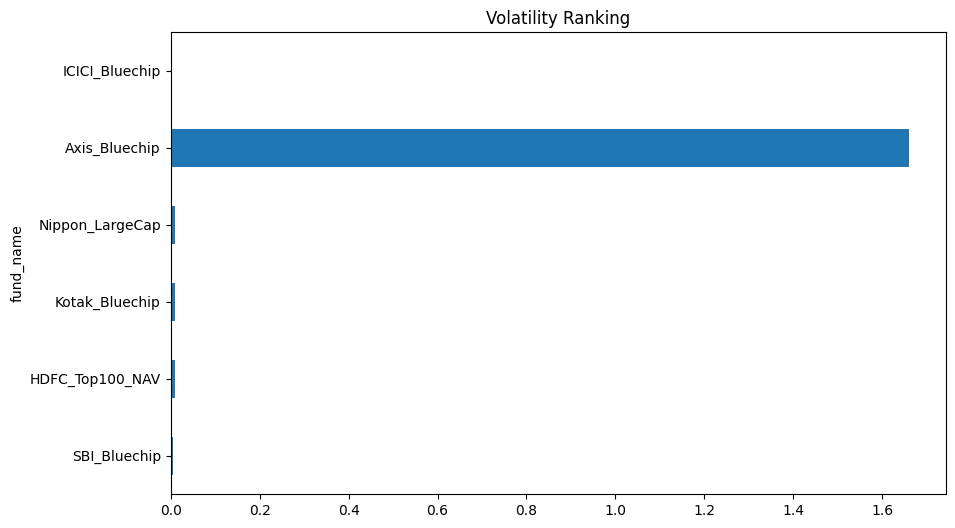

In [11]:
import matplotlib.pyplot as plt

volatility = df.groupby(
    "fund_name"
)["daily_return"].std()

volatility.sort_values().plot(
    kind="barh",
    figsize=(10,6)
)

plt.title("Volatility Ranking")

plt.savefig(
    "../reports/volatility_ranking.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()